In [2]:
#Classical Hodgkin-Huxley model under constant current injection.

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


__all__ = ["hh_sim"]


# ---- gating rate functions (ms^-1), with removable singularities patched ----
def _am(V):
    return 1.0 if abs(V - 25) < 1e-6 else 0.1 * (25 - V) / (np.exp((25 - V) / 10) - 1)


def _bm(V):
    return 4 * np.exp(-V / 18)


def _ah(V):
    return 0.07 * np.exp(-V / 20)


def _bh(V):
    return 1 / (np.exp((30 - V) / 10) + 1)


def _an(V):
    return 0.1 if abs(V - 10) < 1e-6 else 0.01 * (10 - V) / (np.exp((10 - V) / 10) - 1)


def _bn(V):
    return 0.125 * np.exp(-V / 80)


def hh_sim(Id=7.0, tmax=300.0, gK=36.0, gNa=120.0, skipfrac=0.4):
   
    C, gL, ENa, EK, EL = 1.0, 0.3, 115.0, -12.0, 10.6

    def rhs(_, y):
        V, m, h, n = y
        INa = gNa * m**3 * h * (V - ENa)
        IK = gK * n**4 * (V - EK)
        IL = gL * (V - EL)
        return [
            (Id - INa - IK - IL) / C,
            _am(V) * (1 - m) - _bm(V) * m,
            _ah(V) * (1 - h) - _bh(V) * h,
            _an(V) * (1 - n) - _bn(V) * n,
        ]

    V0 = 0.0  # steady state gating at rest
    y0 = [
        V0,
        _am(V0) / (_am(V0) + _bm(V0)),
        _ah(V0) / (_ah(V0) + _bh(V0)),
        _an(V0) / (_an(V0) + _bn(V0)),
    ]

    t = np.arange(0, tmax + 1e-9, 0.01)
    sol = solve_ivp(rhs, [0, tmax], y0, method="BDF", t_eval=t,
                    rtol=1e-8, atol=1e-10, max_step=0.05)
    V = sol.y[0]

    i0 = max(1, int(round(skipfrac * len(t))))
    up = np.flatnonzero((V[i0:-1] < 40) & (V[i0 + 1:] >= 40)) + i0
    spk = t[up]

    rate = 1000 * (len(spk) - 1) / (spk[-1] - spk[0]) if len(spk) >= 2 else 0.0
    return t, V, spk, rate


if __name__ == "__main__":
    t, V, spk, rate = hh_sim()
    print(f"Id = 7: {len(spk)} spikes, rate = {rate:.1f} Hz")


Id = 7: 11 spikes, rate = 58.3 Hz


Rheobase = 6.256


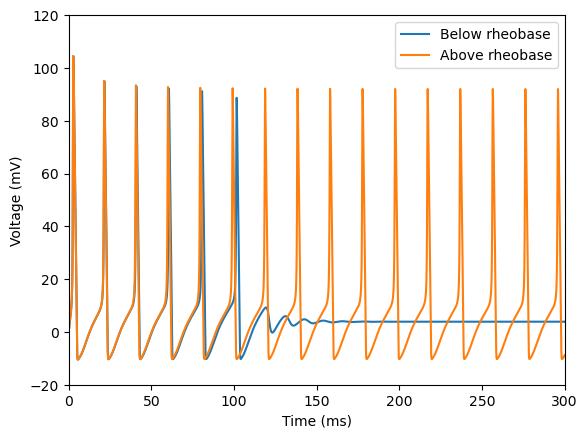

In [3]:
#part a: rheobase
#criterion - how many spikes and when these occur later into the simulation
#for this problem, the criterion used is 2 spikes occuring during the final 60% of the simulation.

def find_rheobase(minI, maxI, num_spikes, gK):
    
    while (maxI - minI) > 0.001:
        middle = (minI + maxI) / 2
        t,V,spk,rate = hh_sim(Id=middle, gK=gK, skipfrac = 0.4)

        if len(spk) >= num_spikes:
            maxI = middle
        else:
            minI = middle

    return maxI


rheobase = find_rheobase(5, 10, 2, 36)
print(f"Rheobase = {rheobase:.3f}")

lower = rheobase - 0.01
higher = rheobase + 0.01


t1, V1, spk1, rate1 = hh_sim(Id=lower,gK = 36, skipfrac=0.4)
t2, V2, spk2, rate2 = hh_sim(Id=higher, gK=36,skipfrac=0.4)

plt.plot(t1, V1, label="Below rheobase")
plt.plot(t2, V2, label="Above rheobase")

plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.xlim(0, 300)
plt.ylim(-20, 120)
plt.legend()
plt.show()

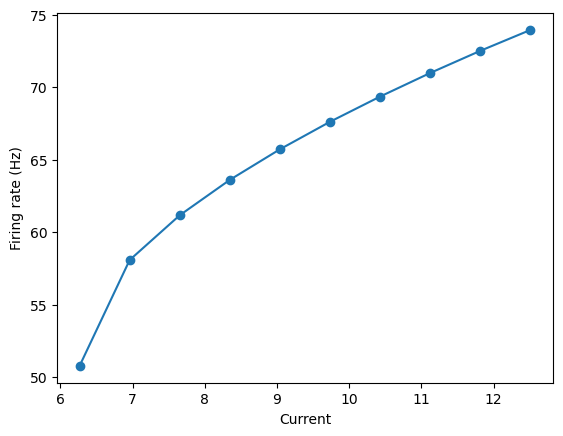

Onset rate = 50.794 Hz


In [4]:
#part b: Compute the firing rate at a sequence of currents from just above rheobase up to roughly twice it, plot the f–I curve, and report the onset rate to three digits

currents = np.linspace(higher, 2 * rheobase, 10)

rates = []

for I in currents:
    t, V, spk, rate = hh_sim(Id=I, skipfrac=0.4)
    rates.append(rate)

plt.plot(currents, rates, 'o-')
plt.xlabel("Current")
plt.ylabel("Firing rate (Hz)")
plt.show()

onset = rates[0]
print(f"Onset rate = {onset:.3f} Hz")

Given the printed onset rate, the rate is not rising from 0, rather it switches on at a nonzero firing rate. Given this, the Hodgkin-Huxley model closely resembles the bifurcation scenario of problem 2, as problem 3 begins firing at zero. Applying this to physiology, this means that there is no continuous rise in firing rate, rather it switches from rest to repetivie firing at a relatively high frequency after passing the threshold.

gK = 30: 5.001
gK = 36: 6.256
onset for gK = 30: 60.94216588457552
onset for gK= 36: 50.793650793650784


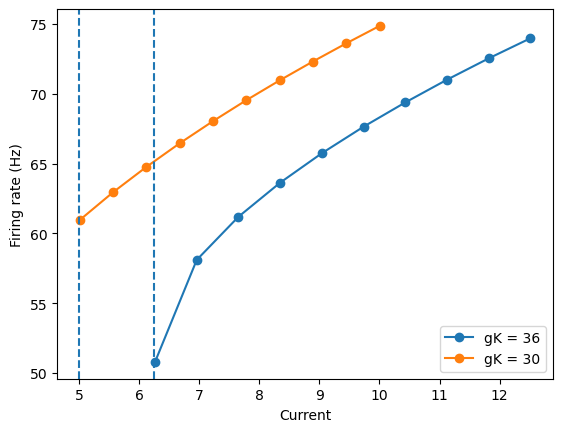

In [5]:
rheobase_30 = find_rheobase(5,10,2,30)
rheobase_36 = find_rheobase(5, 10, 2, 36)
print(f"gK = 30: {rheobase_30:.3f}")
print(f"gK = 36: {rheobase_36:.3f}")

currents_30 = np.linspace(rheobase_30 + 0.01, 2 * rheobase_30, 10)
currents_36 = np.linspace(rheobase_36 + 0.01, 2 * rheobase_36, 10)


rates_c30 = []
rates_c36 = []

for I in currents_30:
    t, V, spk, rate = hh_sim(Id=I,gK=30, skipfrac=0.4)
    rates_c30.append(rate)

for I in currents_36:
    t, V, spk, rate = hh_sim(Id=I,gK=36, skipfrac=0.4)
    rates_c36.append(rate)

onset_30 = rates_c30[0]
print(f"onset for gK = 30: {onset_30}")
onset_36 = rates_c36[0]
print(f"onset for gK= 36: {onset_36}")

plt.plot(currents_36, rates_c36, 'o-', label="gK = 36")
plt.plot(currents_30, rates_c30, 'o-', label="gK = 30")

plt.axvline(rheobase_36, linestyle='--')
plt.axvline(rheobase_30, linestyle='--')

plt.xlabel("Current")
plt.ylabel("Firing rate (Hz)")
plt.legend()
plt.show()

The rheobase decreased, signifying than a smaller current is required to set off an action potential.  When gK is decreased,  the potassium current becomes smaller. Potassium opposes depolarization of the neuron, so a weaker current makes it easier for an action potential to be triggered. Looking at the f-I curve, the onsets are fairly different, which makes sense as a lower rheobase means a neuron can enter repetivie firing at a higher frequency. The general shape of the curve did stay the same, minus the harsher bend on the curve for gK=36.